<a href="https://colab.research.google.com/github/HaseebUlHassan437/weights-initialization/blob/main/weights_inintialization_problem_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Always initialize with random but not very small range to avoid Vanishing gradients problem , Not bigger ranges to avoid late convergance or exploiding  problem...**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ushape.csv')

In [6]:
df.columns = ['X', 'Y', 'class']

In [7]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


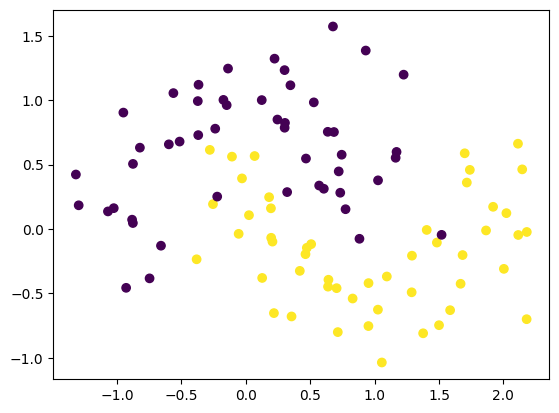

In [8]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [9]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [10]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [12]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.get_weights()

[array([[ 1.1338369 ,  1.912356  ,  1.4990362 ,  0.88530296,  0.8965038 ,
         -1.266893  , -1.1175562 ,  0.8647947 , -0.428795  , -0.5390675 ],
        [ 1.5541683 , -1.4774739 , -0.01760545, -0.15883186, -0.2448105 ,
          0.32948896,  1.7505006 ,  0.98221356,  0.5402852 ,  0.16666192]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.47396252,  0.43527243, -0.08628617, -0.6551041 ,  0.12937354,
         -0.6261329 ,  0.14154361, -0.31972724, -0.43110833,  0.76651317],
        [-0.4110784 ,  0.1822571 , -0.5362129 , -0.16954722,  0.94829565,
          0.44628945,  0.6470867 ,  0.431437  ,  0.53286225, -0.38199663],
        [-0.6944184 ,  0.08227248,  0.39408734,  0.6590165 , -0.1242966 ,
         -0.25844082,  0.2968143 ,  0.13233984,  0.14030035, -0.78688747],
        [ 0.705861  ,  0.3259752 ,  0.39252555, -0.11673176, -0.40401822,
          0.699136  , -0.04343183,  0.24949583, -0.591007  , -0.2750672 ],
        [-0.03302

In [15]:
initial_weights = model.get_weights()

In [ ]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [16]:
model.set_weights(initial_weights)

In [17]:
model.get_weights()

[array([[ 1.1338369 ,  1.912356  ,  1.4990362 ,  0.88530296,  0.8965038 ,
         -1.266893  , -1.1175562 ,  0.8647947 , -0.428795  , -0.5390675 ],
        [ 1.5541683 , -1.4774739 , -0.01760545, -0.15883186, -0.2448105 ,
          0.32948896,  1.7505006 ,  0.98221356,  0.5402852 ,  0.16666192]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.47396252,  0.43527243, -0.08628617, -0.6551041 ,  0.12937354,
         -0.6261329 ,  0.14154361, -0.31972724, -0.43110833,  0.76651317],
        [-0.4110784 ,  0.1822571 , -0.5362129 , -0.16954722,  0.94829565,
          0.44628945,  0.6470867 ,  0.431437  ,  0.53286225, -0.38199663],
        [-0.6944184 ,  0.08227248,  0.39408734,  0.6590165 , -0.1242966 ,
         -0.25844082,  0.2968143 ,  0.13233984,  0.14030035, -0.78688747],
        [ 0.705861  ,  0.3259752 ,  0.39252555, -0.11673176, -0.40401822,
          0.699136  , -0.04343183,  0.24949583, -0.591007  , -0.2750672 ],
        [-0.03302

In [18]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [19]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.7207 - loss: 0.5090 - val_accuracy: 0.8500 - val_loss: 0.4795
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7162 - loss: 0.5049 - val_accuracy: 0.8500 - val_loss: 0.4715
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7547 - loss: 0.5084 - val_accuracy: 0.8500 - val_loss: 0.4628
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7094 - loss: 0.5154 - val_accuracy: 0.8500 - val_loss: 0.4541
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7767 - loss: 0.4695 - val_accuracy: 0.8500 - val_loss: 0.4458
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8119 - loss: 0.4664 - val_accuracy: 0.8500 - val_loss: 0.4375
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7650 - loss: 0.4584 - val_accuracy: 0.8500 - val_loss: 0.4289
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8026 - loss: 0.4619 - val_accuracy: 0.8500 - val_loss

In [ ]:
model.get_weights()

[array([[-0.7534644 , -0.40642726, -0.46373174, -0.7715832 , -0.1277438 ,
         -0.2729551 ,  0.34282172, -0.2771892 , -0.26632193, -1.429772  ],
        [ 1.0737787 ,  0.47488663,  0.62465155, -0.12547861,  0.20325062,
         -0.28902182, -0.28489602, -0.7651134 ,  0.32014093,  0.38592413]],
       dtype=float32),
 array([ 0.17320989,  0.00114872,  0.0397424 , -0.13545433,  0.00454802,
        -0.22851905, -0.04516467,  0.15110366, -0.06830908,  0.17423655],
       dtype=float32),
 array([[ 0.07947282,  0.26585355,  0.15415847, -0.25968108, -0.01067472,
          0.37633535,  0.03868366, -0.38048545, -0.19025889, -0.65158546],
        [-0.85772514, -0.04266584,  0.12410757, -0.38518146,  0.4134989 ,
         -0.11743478, -0.66751945,  0.37822312, -0.16036926, -0.14447264],
        [-0.14926817, -0.04317714,  0.24179652, -0.20616755,  0.4172752 ,
         -0.737155  , -0.17425217,  0.3156445 , -0.3552739 , -0.395115  ],
        [-0.26271275, -0.16797927,  0.30563584, -0.03270569, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

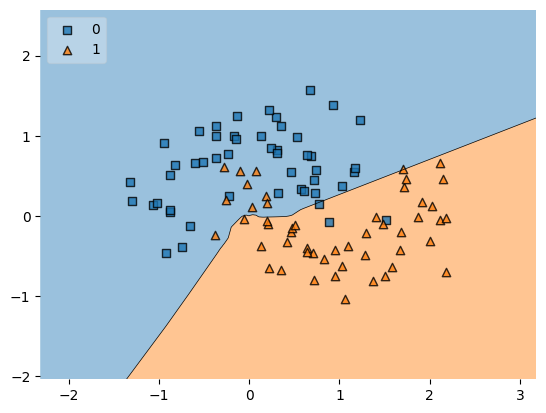

In [20]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [21]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.022661293497061207)

In [22]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.02614199437996743)